In [1]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from sklearn import metrics
from sklearn.metrics.pairwise import rbf_kernel

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap
from GroundTruthExperiment import GroundTruthExperiment

_, loader_test = ReturnLoaders(data_name="pima", download=False, batch_size=128)
X_test = loader_test.dataset.data
y_test = loader_test.dataset.targets.to_numpy()
model = LoadModel(data_name="pima", ml_model="ann", pretrained=True)
model.eval()

ArtificialNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )
)

# Ground Truth

In [2]:
ground_truth = GroundTruthExperiment(
    dataset_name="german",
    X_test=X_test,
    y_test=y_test,
    model=model,n_repeats=3, 
)
ground_truth.perform()

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Running ground truth calculation iteration 1/3
Calculating ground truth for estimator: kernel, explainer: shap
Calculating ground truth for estimator: permutation, explainer: sage


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Running ground truth calculation iteration 2/3
Calculating ground truth for estimator: kernel, explainer: shap
Calculating ground truth for estimator: permutation, explainer: sage


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Running ground truth calculation iteration 3/3
Calculating ground truth for estimator: kernel, explainer: shap
Calculating ground truth for estimator: permutation, explainer: sage
Saved aggregated results to metadata/german/ground_truth_0_3.npz for german with 3 repeats.


In [26]:
data = np.load("metadata/german/ground_truth_0_3.npz", allow_pickle=True)
data

NpzFile 'metadata/german/ground_truth_0_3.npz' with keys: dataset_name, method, estimator, explanation, kernel...

# Changing G Experiment

In [2]:
from ParameterGExperiment import ParameterGExperiment

changing_g = ParameterGExperiment(
    dataset_name="pima",
    X_test=X_test,
    y_test=y_test,
    model=model,
    n_repeats=2,
    g_values = None,
    kernel = b"gaussian",
    num_bins = 4, 
    experiment_name="changing_g_num_bins_4_n_repeats_10",
    description="Testing different g values for German dataset, using num_bins=4 and n_repeats=2",
)

changing_g.perform()

Running for repeat: 1  g_values:  <list_reverseiterator object at 0x16302f8b0>
Running experiment for g=2, method=cte, estimator=kernel, explanation=shap, repeat=1/2
Running experiment for g=2, method=cte_predictions, estimator=kernel, explanation=shap, repeat=1/2
Running experiment for g=2, method=cte_stratified, estimator=kernel, explanation=shap, repeat=1/2
Running experiment for g=2, method=cte, estimator=permutation, explanation=sage, repeat=1/2
PermutationEstimator will use 16 jobs
Running experiment for g=2, method=cte_predictions, estimator=permutation, explanation=sage, repeat=1/2
PermutationEstimator will use 16 jobs
Running experiment for g=2, method=cte_stratified, estimator=permutation, explanation=sage, repeat=1/2
PermutationEstimator will use 16 jobs
Running experiment for g=1, method=cte, estimator=kernel, explanation=shap, repeat=1/2
Running experiment for g=1, method=cte_predictions, estimator=kernel, explanation=shap, repeat=1/2
Running experiment for g=1, method=cte

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import math

data = np.load(f"metadata/compas/changing_g_num_bins_4_n_repeats_10/changing_g.npz", allow_pickle=True)

filtered_dict = {
    key: data[key] for key in data.files if key != 'explanation_values' and key != 'id_compressed'
}

df = pd.DataFrame(filtered_dict)
df_shap = df[df['explanation'] == 'shap']
df_sage = df[df['explanation'] == 'sage']


In [19]:
len(data['compression_time'])

230

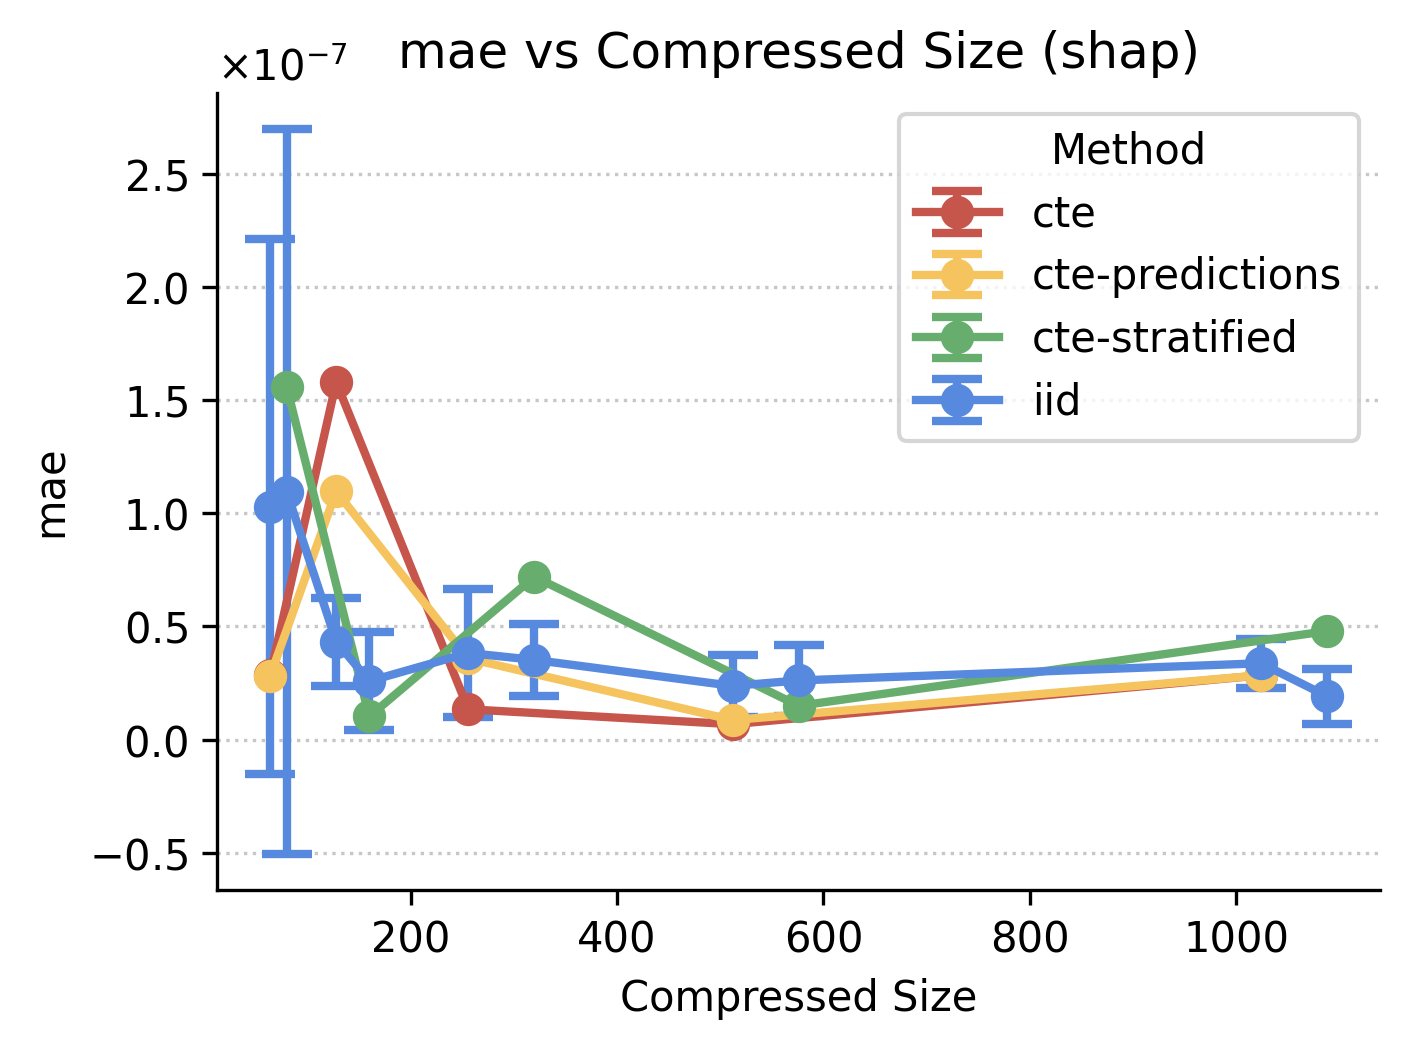

In [4]:
y_name ="mae"
df = df_shap

grouped = df.groupby(["method", "compressed_size"]).agg(
    mean=(y_name, "mean"),
    std=(y_name, "std")
).reset_index()

colors = {
    "iid": "#578ade",
    "cte": "#c6554c",
    "cte_stratified": "#67AE6E",
    "cte_predictions": "#F5C45E",
}

method_labels = {
    "iid": "iid",
    "cte": "cte",
    "cte_stratified": "cte-stratified",
    "cte_predictions": "cte-predictions",
}

fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=300)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

for method in grouped['method'].unique():
    method_data = grouped[grouped['method'] == method]
    x = method_data['compressed_size']
    y = method_data['mean']
    yerr = method_data['std']
    
    ax.errorbar(
        x=x, y=y, yerr=yerr,
        fmt='o-', label=method_labels.get(method, method),
        color=colors.get(method, None),
        markersize=7, capsize=6, linewidth=2, capthick=2
    )

ax.set_xlabel("Compressed Size")
ax.set_ylabel(y_name)
ax.set_title(f"{y_name} vs Compressed Size ({"shap"})")
ax.legend(title="Method")
ax.grid(axis='y', linestyle='dotted', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

In [7]:
df_sage[df_sage['method']=='cte']

,dataset_name,method,estimator,explanation,kernel,g,num_bins,seed_compression,seed_explanation,compressed_size,original_size,compression_time,explanation_time,mae,top_k,mmd
3,compas,cte,permutation,sage,b'gaussian',4,4,100,1,1024,1235,0.000147,871.885814,0.006179,1.0,0.000004
9,compas,cte,permutation,sage,b'gaussian',3,4,100,1,512,1235,0.009331,180.451757,0.014128,0.8,0.000016
15,compas,cte,permutation,sage,b'gaussian',2,4,100,1,256,1235,0.004769,119.738844,0.012386,1.0,0.000009
21,compas,cte,permutation,sage,b'gaussian',1,4,100,1,128,1235,0.001878,19.419264,0.051062,1.0,0.000190
27,compas,cte,permutation,sage,b'gaussian',0,4,100,1,64,1235,0.000888,8.521234,0.031283,0.8,0.000053


In [8]:
df_sage

,dataset_name,method,estimator,explanation,kernel,g,num_bins,seed_compression,seed_explanation,compressed_size,original_size,compression_time,explanation_time,mae,top_k,mmd
3,compas,cte,permutation,sage,b'gaussian',4,4,100,1,1024,1235,0.000147,871.885814,0.006179,1.0,0.000004
4,compas,cte_predictions,permutation,sage,b'gaussian',4,4,100,1,1024,1235,0.074267,867.541457,0.006179,1.0,0.000004
5,compas,cte_stratified,permutation,sage,b'gaussian',4,4,100,1,1088,1235,0.005206,412.478625,0.006876,0.8,0.000003
9,compas,cte,permutation,sage,b'gaussian',3,4,100,1,512,1235,0.009331,180.451757,0.014128,0.8,0.000016
10,compas,cte_predictions,permutation,sage,b'gaussian',3,4,100,1,512,1235,0.04297,309.751073,0.009417,1.0,0.000009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,compas,iid,permutation,sage,None,None,None,109,10,320,1235,0.000226,105.364097,0.009231,0.8,0.000006
223,compas,iid,permutation,sage,None,None,None,109,10,128,1235,0.000113,17.660592,0.020378,1.0,0.000054
225,compas,iid,permutation,sage,None,None,None,109,10,160,1235,0.000158,34.705618,0.028432,0.8,0.000052
227,compas,iid,permutation,sage,None,None,None,109,10,64,1235,0.000112,17.571125,0.024571,1.0,0.000039


In [10]:
df_sage.head(20)

,dataset_name,method,estimator,explanation,kernel,g,num_bins,seed_compression,seed_explanation,compressed_size,original_size,compression_time,explanation_time,mae,top_k,mmd
3,compas,cte,permutation,sage,b'gaussian',4,4,100,1,1024,1235,0.000147,871.885814,0.006179,1.0,3.504169e-06
4,compas,cte_predictions,permutation,sage,b'gaussian',4,4,100,1,1024,1235,0.074267,867.541457,0.006179,1.0,3.504169e-06
5,compas,cte_stratified,permutation,sage,b'gaussian',4,4,100,1,1088,1235,0.005206,412.478625,0.006876,0.8,3.410072e-06
9,compas,cte,permutation,sage,b'gaussian',3,4,100,1,512,1235,0.009331,180.451757,0.014128,0.8,1.639665e-05
10,compas,cte_predictions,permutation,sage,b'gaussian',3,4,100,1,512,1235,0.04297,309.751073,0.009417,1.0,8.509931e-06
11,compas,cte_stratified,permutation,sage,b'gaussian',3,4,100,1,576,1235,0.070865,542.495252,0.013410,0.8,1.380545e-05
15,compas,cte,permutation,sage,b'gaussian',2,4,100,1,256,1235,0.004769,119.738844,0.012386,1.0,8.972331e-06
16,compas,cte_predictions,permutation,sage,b'gaussian',2,4,100,1,256,1235,0.046201,188.451563,0.012030,1.0,1.097519e-05
17,compas,cte_stratified,permutation,sage,b'gaussian',2,4,100,1,320,1235,0.006492,313.298604,0.010768,0.8,9.340010e-06
21,compas,cte,permutation,sage,b'gaussian',1,4,100,1,128,1235,0.001878,19.419264,0.051062,1.0,1.902315e-04
